In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten,Dense,Dropout
from tensorflow.keras.models import load_model

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
y_train.shape

(60000,)

In [6]:
y_test.shape

(10000,)

In [7]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

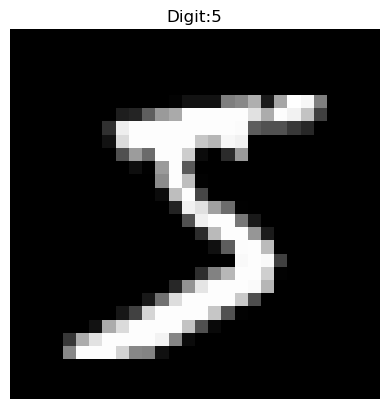

In [8]:
plt.imshow(X_train[0],cmap='gray')
plt.title(f"Digit:{y_train[0]}")
plt.axis('off')
plt.show()

In [9]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.3),
    Dense(10,activation='softmax')
])

C:\Users\Arati\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history=model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8677 - loss: 0.4332 - val_accuracy: 0.9522 - val_loss: 0.1595
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9364 - loss: 0.2166 - val_accuracy: 0.9647 - val_loss: 0.1262
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9485 - loss: 0.1746 - val_accuracy: 0.9691 - val_loss: 0.1091
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9538 - loss: 0.1537 - val_accuracy: 0.9695 - val_loss: 0.1012
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9608 - loss: 0.1316 - val_accuracy: 0.9726 - val_loss: 0.0966
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9628 - loss: 0.1206 - val_accuracy: 0.9752 - val_loss: 0.0930
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9665 - loss: 0.1102 - val_accuracy: 0.9739 - val_loss: 0.0957
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9676 - lo

In [13]:
test_acc,test_loss=model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9764 - loss: 0.0872


In [14]:
test_acc

0.0872141569852829

In [15]:
test_loss

0.9764000177383423

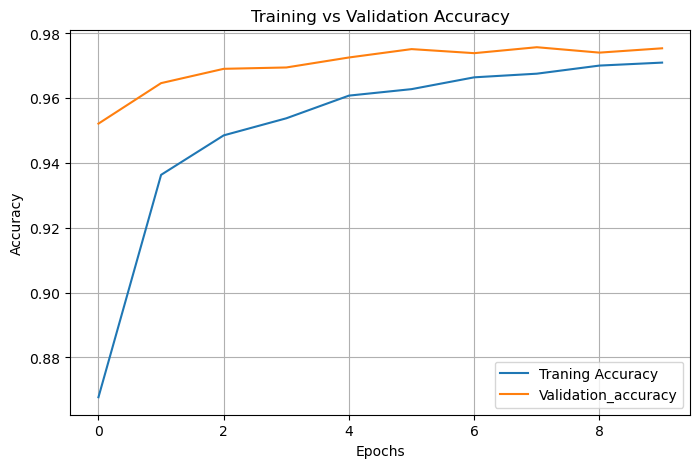

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Traning Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

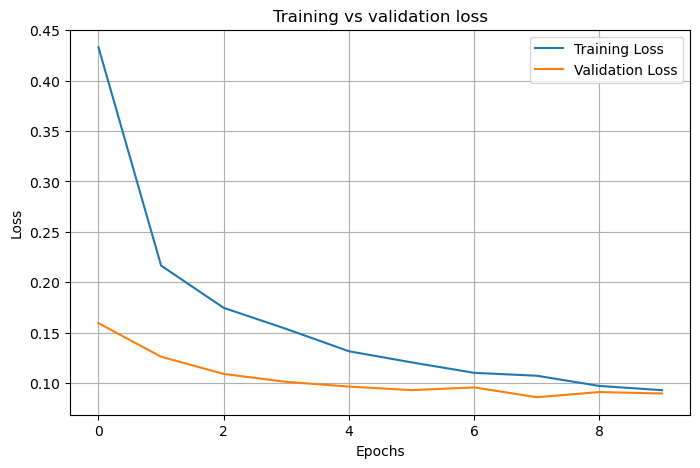

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs validation loss')
plt.legend()
plt.grid()
plt.show()

In [18]:
model.save('mnist_digit_model.keras')

print('Model saved successfully!')

print('file exists:',os.path.exists('mnist_digit_model.keras'))

Model saved successfully!
file exists: True


In [19]:
# load model

saved_model=load_model('mnist_digit_model.keras')
print('Saved model loaded successfully!')

Saved model loaded successfully!


In [20]:
#make prediction

predictions=saved_model.predict(X_test)
predicted_labels=np.argmax(predictions,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [21]:
predictions

array([[2.2842172e-13, 1.3020086e-10, 5.7667268e-08, ..., 9.9999917e-01,
        2.4293088e-11, 1.5677369e-07],
       [3.3498516e-13, 4.5274673e-03, 9.9546993e-01, ..., 4.8972555e-09,
        1.4195280e-10, 1.9335159e-13],
       [9.3836737e-11, 9.9996328e-01, 2.1524671e-07, ..., 2.4477706e-05,
        1.1126247e-05, 4.6298894e-08],
       ...,
       [1.6791214e-12, 1.5913304e-10, 1.7277358e-09, ..., 1.1977372e-07,
        7.5627664e-09, 1.3653558e-06],
       [9.8299996e-14, 1.6030010e-12, 3.1553753e-14, ..., 1.3736756e-14,
        7.2335013e-08, 6.5397139e-11],
       [1.6885950e-12, 4.1357525e-17, 2.1466071e-13, ..., 1.3908399e-20,
        1.4821219e-11, 7.4521702e-18]], shape=(10000, 10), dtype=float32)

In [22]:
#find wrong predictions

wrong_indices=np.where(predicted_labels != y_test)[0]
print('Number of wrong predictions:',len(wrong_indices))

Number of wrong predictions: 236


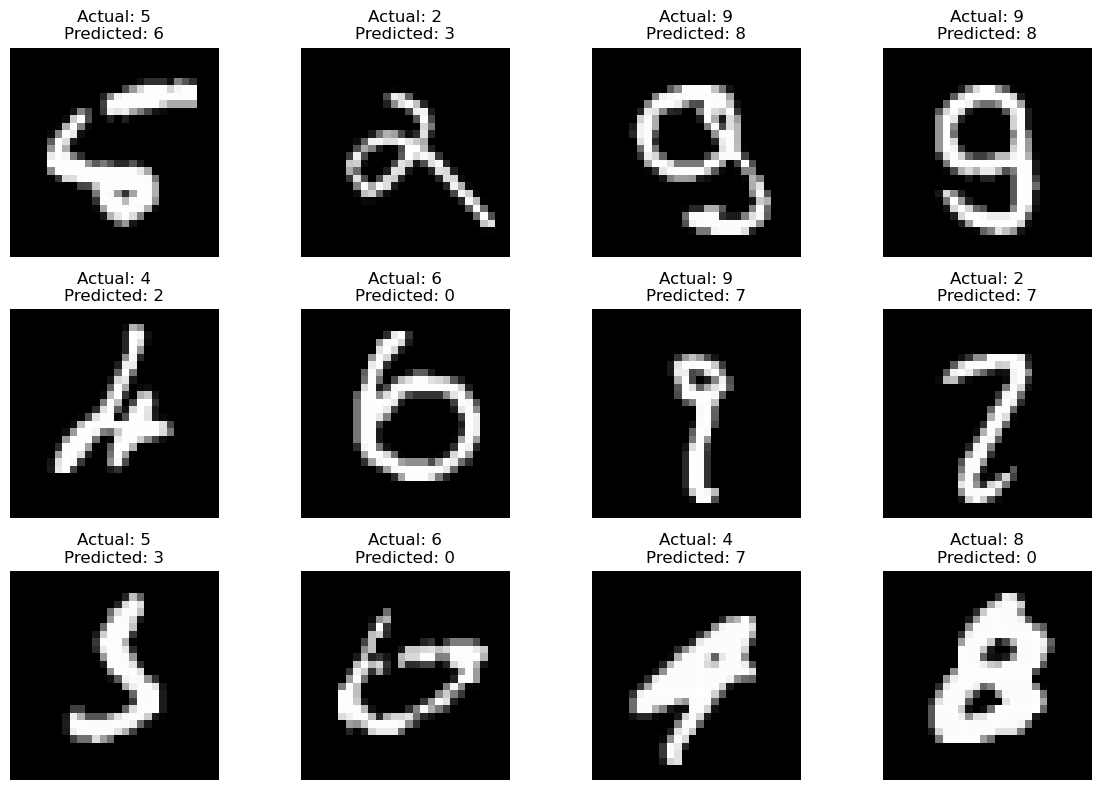

In [23]:
plt.figure(figsize=(12,8))

for i, index in enumerate(wrong_indices[:12]):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[index],cmap='gray')
    plt.title(f'Actual: {y_test[index]}\n'  f'Predicted: {predicted_labels[index]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

Image loaded successfully!
Image size: (1152, 648)


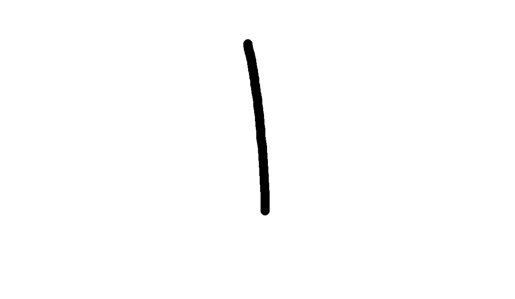

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("my_digit.png")

print("Image loaded successfully!")
print("Image size:", img.size)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predicted Digit: 1


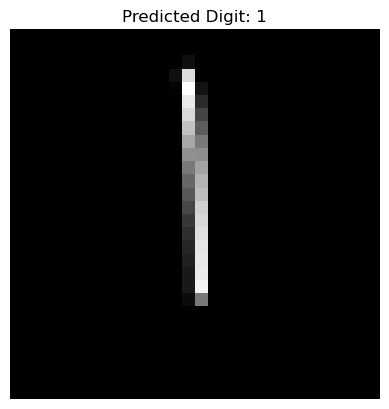

In [34]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("my_digit.png").convert("L")

# Resize to 28x28
img = img.resize((28, 28))

# Convert to NumPy
img_array = np.array(img)

# Normalize
img_array = img_array.astype("float32") / 255.0

# Invert image
img_array = 1 - img_array

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Get predicted digit
digit = np.argmax(prediction, axis=1)[0]

print("Predicted Digit:", digit)

# Show image
plt.imshow(img_array[0], cmap="gray")
plt.title(f"Predicted Digit: {digit}")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Digit: 1


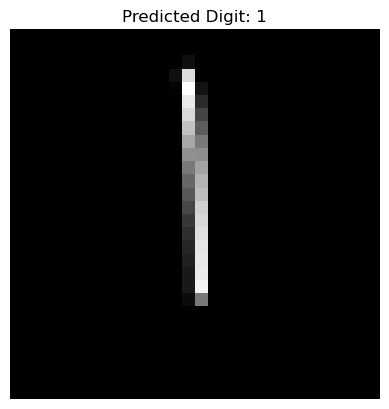

In [35]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("my_digit.png").convert("L")

img = img.resize((28, 28))

img_array = np.array(img)

img_array = img_array.astype("float32") / 255.0

# Agar background white aur digit black hai
img_array = 1 - img_array

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

digit = np.argmax(prediction, axis=1)[0]

print("Predicted Digit:", digit)

plt.imshow(img_array[0], cmap="gray")
plt.title(f"Predicted Digit: {digit}")
plt.axis("off")
plt.show()